In [1]:
"""
Baseline Transmission Efficiency Diagnostics
==============================================
Produces:
  - Figure 3.5: Detector count rate vs. aperture-derived ion rate
  - Figure 3.6: Detected percentage (Pdet) vs. source heating power

Baseline configuration: source + two apertures (A1 = 0.5 mm, connected to
the picoammeter; A2 = 1.12 mm) + MagneTOF detector, at 2400 V detector bias
and -7 mV MPANT threshold. This is the only correct/final baseline dataset;
earlier attempts at a different bias (1800 V) and using the larger A2
aperture as the measurement point were superseded and are not included here.
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import matplotlib.colors as mcolors

In [2]:
def read_mpa_file(filepath):
    """Reads an MPA file and returns (realtime, totalsum) from its ASCII header."""
    realtime = None
    totalsum = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())

    return realtime, totalsum


# Naming scheme: Efficiency{amps}_{run}.mpa, where {amps} is a 4-digit code
# in thousandths of an amp (e.g. "0950" -> 0.950 A).
def get_amps(filename, prefix):
    name_only = filename.replace(prefix, "").replace(".mpa", "")
    name_only = name_only.split("_")[0]
    return int(name_only) / 1000


def get_run(filename, prefix):
    """Extracts the run number from a {prefix}*.mpa filename (defaults to 1 if unlabeled)."""
    name_only = filename.replace(prefix, "").replace(".mpa", "")
    if "_" in name_only:
        return int(name_only.split("_")[1])
    return 1


def build_df(data_folder, glob_pattern, prefix, exclude=None):
    rows = []
    for filepath in glob.glob(os.path.join(data_folder, glob_pattern)):
        filename = os.path.basename(filepath)
        if exclude and exclude in filename:
            continue  # skip files that belong to the other set

        amps = get_amps(filename, prefix)
        realtime, totalsum = read_mpa_file(filepath)
        rate = totalsum / realtime
        run = get_run(filename, prefix)

        rows.append({
            "amps": amps,
            "file": filename,
            "run": run,
            "realtime_s": realtime,
            "totalsum": totalsum,
            "rate_hz": rate
        })
    return pd.DataFrame(rows)


data_folder = "EfficiencyControl"
efficiency_df = build_df(data_folder, "Efficiency*.mpa", "Efficiency", exclude="Noise")
efficiency_df = efficiency_df.sort_values(by=["amps", "run"]).reset_index(drop=True)
efficiency_df['rate_err'] = np.sqrt(efficiency_df['totalsum']) / efficiency_df['realtime_s']  # Poisson error propagation
efficiency_df

,amps,file,run,realtime_s,totalsum,rate_hz,rate_err
0,0.750,Efficiency0750.mpa,1,150.136,9.0,0.059946,0.019982
1,0.800,Efficiency0800.mpa,1,150.101,59.0,0.393069,0.051173
2,0.850,Efficiency0850.mpa,1,150.293,678.0,4.511188,0.173251
3,0.900,Efficiency0900.mpa,1,150.295,9864.0,65.630926,0.660818
4,0.900,Efficiency0900_2.mpa,2,150.117,23.0,0.153214,0.031947
5,0.925,Efficiency0925_2.mpa,2,150.116,65.0,0.432998,0.053707
6,0.950,Efficiency0950.mpa,1,150.101,102486.0,682.780261,2.132793
7,0.950,Efficiency0950_2.mpa,2,150.061,163.0,1.086225,0.085080
8,0.950,Efficiency0950_3.mpa,3,150.032,509186.0,3393.849312,4.756137
9,0.960,Efficiency0960_3.mpa,3,150.001,809285.0,5395.197365,5.997311


In [3]:
"""
Baseline dataset (previously labeled "Run 3"): the correct, final baseline
configuration — A1 (0.5 mm) as the measurement aperture, 2400 V detector
bias. Pressure gauge stable at 3.7e-6 mbar, threshold -7 mV.
"""

baseline = efficiency_df[efficiency_df['run'] == 3].copy()
baseline

,amps,file,run,realtime_s,totalsum,rate_hz,rate_err
8,0.95,Efficiency0950_3.mpa,3,150.032,509186.0,3393.849312,4.756137
9,0.96,Efficiency0960_3.mpa,3,150.001,809285.0,5395.197365,5.997311
10,0.97,Efficiency0970_3.mpa,3,150.017,1308934.0,8725.237806,7.626379
13,0.98,Efficiency0980_3.mpa,3,150.050,2004184.0,13356.774409,9.434802
14,0.99,Efficiency0990_3.mpa,3,150.040,2837854.0,18913.982938,11.227627
17,1.00,Efficiency1000_3.mpa,3,150.031,4105624.0,27365.171198,13.505435


In [4]:
# Picoammeter readings at each current step (pA), 10 repeated readings per step
voltage = [1.94, 1.95, 1.99, 2.02, 2.05, 2.08]  # V, one entry per baseline row, in ascending current order

ap_0950 = [0.60, 0.65, 0.62, 0.79, 0.92, 0.85, 0.73, 0.65, 0.53, 0.48]
ap_0960 = [1.25, 1.08, 0.36, 1.32, 1.39, 1.33, 1.28, 1.23, 1.28, 1.21]
ap_0970 = [1.95, 1.96, 2.29, 2.07, 2.20, 2.18, 2.21, 2.28, 2.10, 2.41]
ap_0980 = [3.86, 3.72, 3.41, 3.67, 3.33, 3.57, 3.61, 3.70, 3.63, 3.64]
ap_0990 = [6.10, 6.08, 5.78, 5.86, 5.66, 6.10, 5.93, 5.76, 5.83, 6.05]
ap_1000 = [10.46, 10.24, 10.04, 10.11, 10.04, 10.06, 10.19, 10.17, 10.30, 10.23]

ap_current_list = [ap_0950, ap_0960, ap_0970, ap_0980, ap_0990, ap_1000]

assert len(voltage) == len(baseline) == len(ap_current_list), (
    "voltage / baseline / ap_current_list lengths don't match — "
    "check that a run wasn't added/removed since these lists were recorded."
)

In [5]:
ap_avgs = []
ap_avgs_err = []
ap_rates = []
ap_rate_errs = []

for amps, ap_current in zip(baseline['amps'], ap_current_list):
    n = len(ap_current)
    avg_current = np.mean(ap_current)  # Mean picoammeter reading for this step (pA)
    avg_current_unc = np.std(ap_current, ddof=1) / np.sqrt(n)  # SEM

    ap_avgs.append(avg_current)
    ap_avgs_err.append(avg_current_unc)

    ap_rate = avg_current * 1e-12 / 1.602e-19  # Ion rate (Hz) from current (pA) / elementary charge
    ap_rate_unc = avg_current_unc * 1e-12 / 1.602e-19
    ap_rates.append(ap_rate)
    ap_rate_errs.append(ap_rate_unc)

baseline['ap_avg'] = ap_avgs
baseline['ap_rate'] = ap_rates
baseline['ap_rate_err'] = ap_rate_errs

In [6]:
baseline['ratio'] = baseline['rate_hz'] / baseline['ap_rate']
baseline['ratio_err'] = np.sqrt(
    (baseline['rate_err'] / baseline['ap_rate'])**2
    + (baseline['rate_hz'] * baseline['ap_rate_err'] / baseline['ap_rate']**2)**2
)
baseline['efficiency'] = baseline['rate_hz'] / (baseline['ap_rate'] + baseline['rate_hz']) * 100
baseline['efficiency_err'] = (
    baseline['efficiency'] * (1 - baseline['efficiency'] / 100)
    * np.sqrt((baseline['rate_err'] / baseline['rate_hz'])**2 + (baseline['ap_rate_err'] / baseline['ap_rate'])**2)
)
print(baseline)

    amps                  file  run  realtime_s   totalsum       rate_hz  \
8   0.95  Efficiency0950_3.mpa    3     150.032   509186.0   3393.849312   
9   0.96  Efficiency0960_3.mpa    3     150.001   809285.0   5395.197365   
10  0.97  Efficiency0970_3.mpa    3     150.017  1308934.0   8725.237806   
13  0.98  Efficiency0980_3.mpa    3     150.050  2004184.0  13356.774409   
14  0.99  Efficiency0990_3.mpa    3     150.040  2837854.0  18913.982938   
17  1.00  Efficiency1000_3.mpa    3     150.031  4105624.0  27365.171198   

     rate_err  ap_avg       ap_rate    ap_rate_err     ratio  ratio_err  \
8    4.756137   0.682  4.257179e+06  275538.000121  0.000797   0.000052   
9    5.997311   1.173  7.322097e+06  587198.024475  0.000737   0.000059   
10   7.626379   2.165  1.351436e+07  289700.427585  0.000646   0.000014   
13   9.434802   3.614  2.255930e+07  299683.260714  0.000592   0.000008   
14  11.227627   5.915  3.692260e+07  316688.567672  0.000512   0.000004   
17  13.505435  10

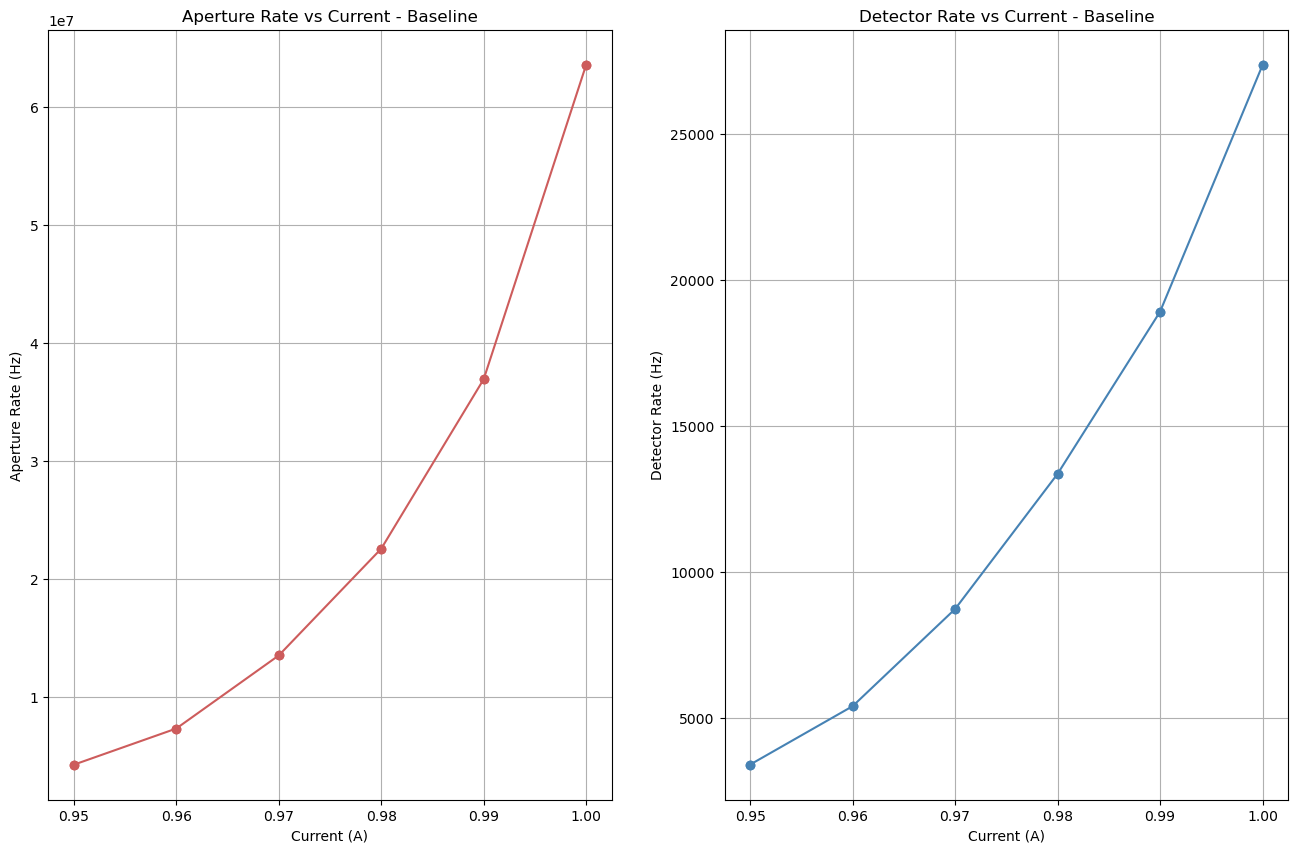

In [7]:
plt.figure(figsize=(16, 10))
plt.subplot(1, 2, 1)
plt.plot(baseline['amps'], baseline['ap_rate'], marker='o', label='Aperture Rate', color='indianred')
plt.errorbar(baseline['amps'], baseline['ap_rate'], yerr=baseline['ap_rate_err'] * 1.602e-19 * 1e12,
             fmt='o', color='indianred', ecolor='indianred', elinewidth=3, capsize=0)
plt.xlabel('Current (A)')
plt.ylabel('Aperture Rate (Hz)')
plt.title('Aperture Rate vs Current - Baseline')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(baseline['amps'], baseline['rate_hz'], marker='o', label='Detector Rate', color='steelblue')
plt.errorbar(baseline['amps'], baseline['rate_hz'], yerr=baseline['rate_err'],
             fmt='o', color='steelblue', ecolor='steelblue', elinewidth=3, capsize=0)
plt.xlabel('Current (A)')
plt.ylabel('Detector Rate (Hz)')
plt.title('Detector Rate vs Current - Baseline')
plt.grid()

plt.show()

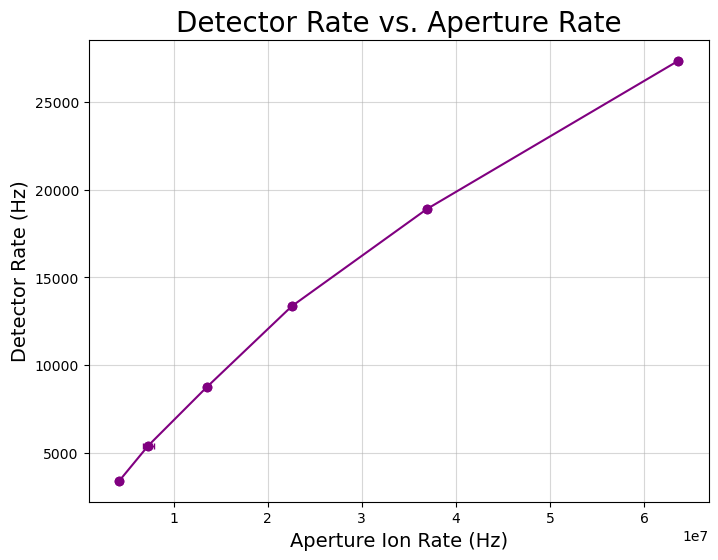

In [8]:
"""
Figure 3.5: Detector Count Rate vs. Aperture-Derived Ion Rate
------------------------------------------------------------------
"""

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(baseline['ap_rate'], baseline['rate_hz'], marker='o', color='purple')
ax.errorbar(baseline['ap_rate'], baseline['rate_hz'], xerr=baseline['ap_rate_err'], yerr=baseline['rate_err'],
            fmt='o', color='purple', ecolor='purple', elinewidth=1, capsize=2)
ax.set_xlabel('Aperture Ion Rate (Hz)', fontsize=14)
ax.set_ylabel('Detector Rate (Hz)', fontsize=14)
ax.set_title('Detector Rate vs. Aperture Rate', fontsize=20)
ax.grid(alpha=0.5)
plt.show()

In [9]:
def export_figure_csv(dataframe, filepath, description_lines):
    """Writes a CSV with a commented header block describing the table's
    purpose and thesis figure reference, followed by the actual data."""
    with open(filepath, "w") as f:
        for line in description_lines:
            f.write(f"# {line}\n")
    dataframe.to_csv(filepath, mode="a", index=False)


description = [
    "Detector Count Rate vs. Aperture-Derived Ion Rate",
    "Corresponds to Figure 3.5",
    "",
    "Purpose: to verify the detector's response tracks source output sensibly",
    "before using it for transmission efficiency measurements. Aperture rate",
    "is an independent estimate of the ion flux entering the beamline,",
    "obtained by converting the picoammeter-measured aperture current to an",
    "equivalent singly-charged ion arrival rate, R_ap = I_ap / e. Comparing",
    "this against the detector's own measured rate at the same heating",
    "current provides a cross-check independent of the detector itself.",
    "",
    "Columns:",
    "  amps          - Source heater current (A)",
    "  ap_avg_pa     - Mean aperture current across repeated readings (pA)",
    "  ap_rate_hz    - Aperture ion rate (Hz) = ap_avg_pa x 1e-12 / e",
    "  ap_rate_err_hz- Propagated uncertainty on aperture ion rate (Hz)",
    "  rate_hz       - Detector ion count rate (Hz)",
    "  rate_err_hz   - Detector rate uncertainty (Hz)",
]

export_cols_map = {
    "amps": "amps",
    "ap_avg": "ap_avg_pa",
    "ap_rate": "ap_rate_hz",
    "ap_rate_err": "ap_rate_err_hz",
    "rate_hz": "rate_hz",
    "rate_err": "rate_err_hz",
}

export_df = baseline[list(export_cols_map.keys())].rename(columns=export_cols_map)
export_df = export_df.sort_values("amps").reset_index(drop=True)

export_figure_csv(export_df, "thesis/detector_vs_aperture_rate.csv", description)
print(export_df)

   amps  ap_avg_pa    ap_rate_hz  ap_rate_err_hz       rate_hz  rate_err_hz
0  0.95      0.682  4.257179e+06   275538.000121   3393.849312     4.756137
1  0.96      1.173  7.322097e+06   587198.024475   5395.197365     5.997311
2  0.97      2.165  1.351436e+07   289700.427585   8725.237806     7.626379
3  0.98      3.614  2.255930e+07   299683.260714  13356.774409     9.434802
4  0.99      5.915  3.692260e+07   316688.567672  18913.982938    11.227627
5  1.00     10.184  6.357054e+07   261080.102228  27365.171198    13.505435


In [10]:
baseline['Power'] = baseline['amps'] * voltage
baseline

,amps,file,run,realtime_s,totalsum,rate_hz,rate_err,ap_avg,ap_rate,ap_rate_err,ratio,ratio_err,efficiency,efficiency_err,Power
8,0.95,Efficiency0950_3.mpa,3,150.032,509186.0,3393.849312,4.756137,0.682,4.257179e+06,275538.000121,0.000797,0.000052,0.079657,0.005153,1.8430
9,0.96,Efficiency0960_3.mpa,3,150.001,809285.0,5395.197365,5.997311,1.173,7.322097e+06,587198.024475,0.000737,0.000059,0.073630,0.005901,1.8720
10,0.97,Efficiency0970_3.mpa,3,150.017,1308934.0,8725.237806,7.626379,2.165,1.351436e+07,289700.427585,0.000646,0.000014,0.064521,0.001383,1.9303
13,0.98,Efficiency0980_3.mpa,3,150.050,2004184.0,13356.774409,9.434802,3.614,2.255930e+07,299683.260714,0.000592,0.000008,0.059172,0.000787,1.9796
14,0.99,Efficiency0990_3.mpa,3,150.040,2837854.0,18913.982938,11.227627,5.915,3.692260e+07,316688.567672,0.000512,0.000004,0.051200,0.000440,2.0295
17,1.00,Efficiency1000_3.mpa,3,150.031,4105624.0,27365.171198,13.505435,10.184,6.357054e+07,261080.102228,0.000430,0.000002,0.043028,0.000178,2.0800


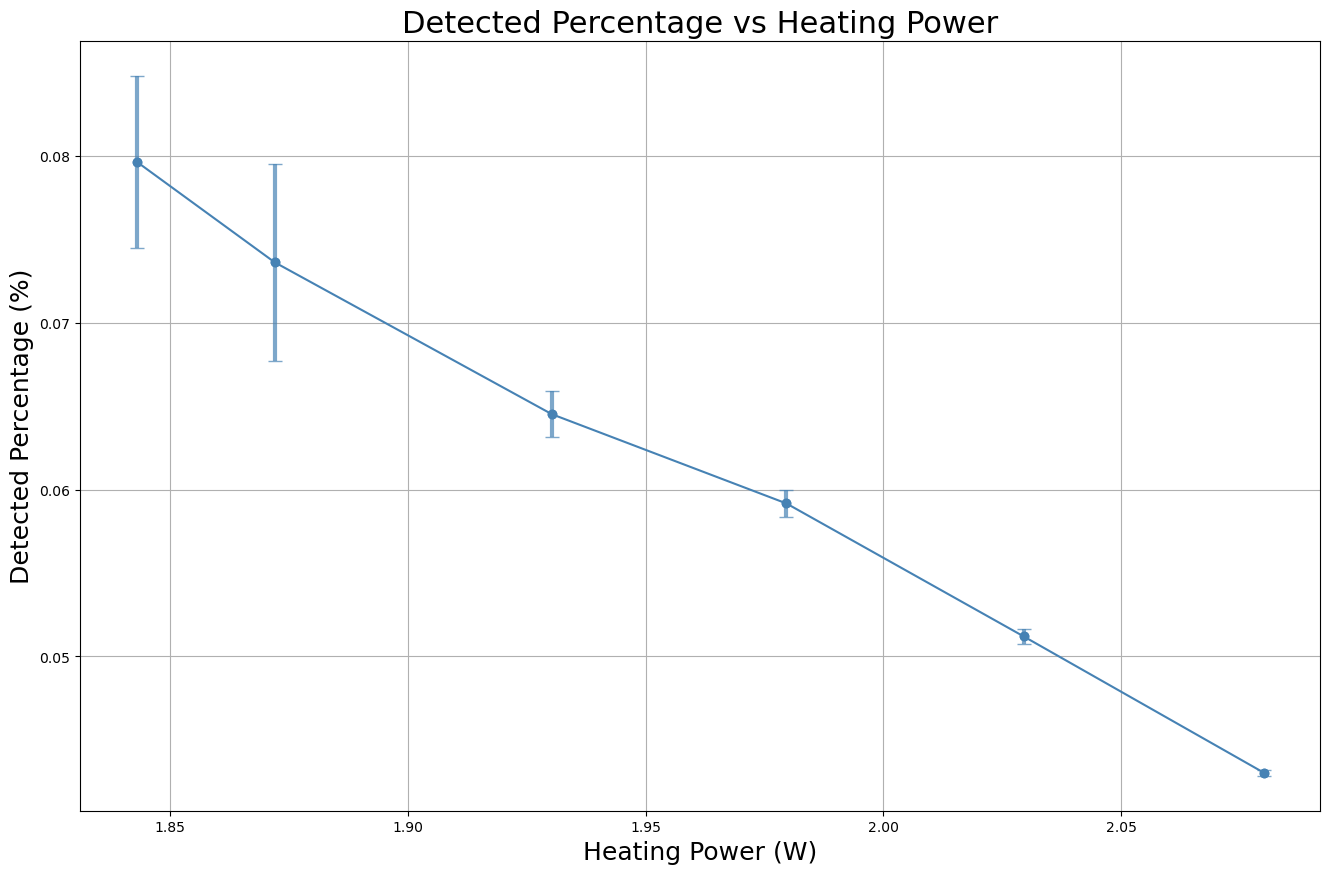

In [11]:
"""
Figure 3.6: Detected Percentage (Pdet) vs. Source Heating Power
--------------------------------------------------------------------
"""

color = 'steelblue'
faded_color = mcolors.to_rgba(color, alpha=0.7)

plt.figure(figsize=(16, 10))
plt.plot(baseline['Power'], baseline['efficiency'], marker='o', label='Detector Rate', color='steelblue')
plt.errorbar(baseline['Power'], baseline['efficiency'], yerr=baseline['efficiency_err'],
             fmt='o', color='steelblue', ecolor=faded_color, elinewidth=3, capsize=5)
plt.xlabel('Heating Power (W)', fontsize=18)
plt.ylabel('Detected Percentage (%)', fontsize=18)
plt.title('Detected Percentage vs Heating Power', fontsize=22)
plt.grid()
plt.show()

In [12]:
description = [
    "Detected Percentage vs. Source Heating Power",
    "Corresponds to Figure 3.6",
    "",
    "Purpose: quantifies what fraction of ions leaving the source (as",
    "estimated from aperture current, Figure 3.5) are actually registered by",
    "the detector, as a function of heating power. Detected percentage is",
    "defined as P_det = R_detected / (R_ap + R_detected) x 100. This",
    "establishes the baseline detector response used for the transmission",
    "efficiency comparison in Chapter 4. The tested heating power range was",
    "bounded by the picoammeter's noise floor at low power and a practical",
    "detector count-rate ceiling (~25,000 Hz) at high power.",
    "",
    "Columns:",
    "  power_w        - Source heating power (W)",
    "  efficiency_pct - Detected percentage (%)",
    "  efficiency_err_pct - Propagated uncertainty on detected percentage (%)",
]

export_cols_map = {
    "Power": "power_w",
    "efficiency": "efficiency_pct",
    "efficiency_err": "efficiency_err_pct",
}

export_df = baseline[list(export_cols_map.keys())].rename(columns=export_cols_map)
export_df = export_df.sort_values("power_w").reset_index(drop=True)

export_figure_csv(export_df, "thesis/efficiency_vs_heating_power.csv", description)
print(export_df)

   power_w  efficiency_pct  efficiency_err_pct
0   1.8430        0.079657            0.005153
1   1.8720        0.073630            0.005901
2   1.9303        0.064521            0.001383
3   1.9796        0.059172            0.000787
4   2.0295        0.051200            0.000440
5   2.0800        0.043028            0.000178


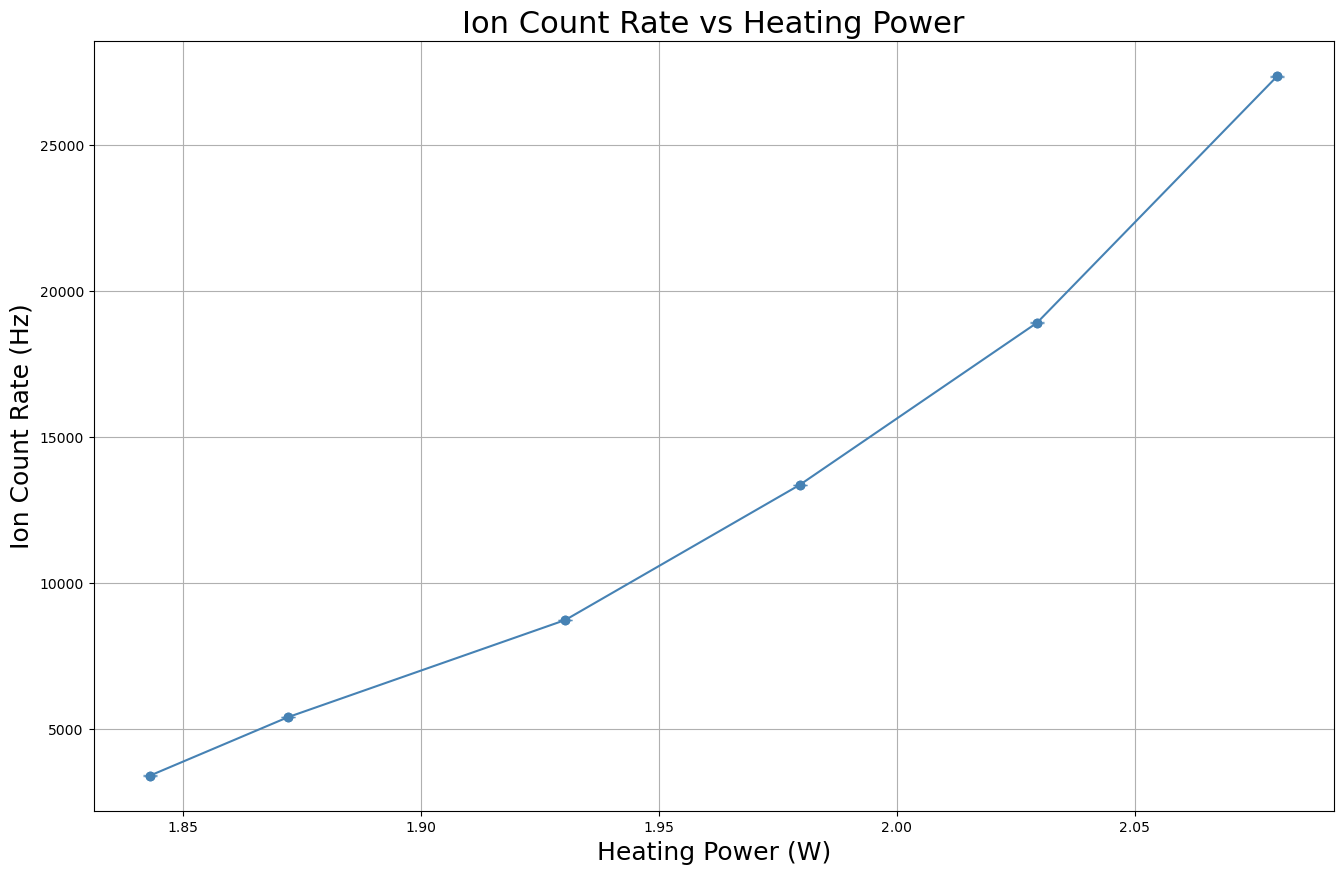

In [13]:
"""
Diagnostic (not a numbered thesis figure): raw detector rate vs. heating
power for the baseline configuration, shown for reference alongside
Figures 3.5/3.6.
"""

color = 'steelblue'
faded_color = mcolors.to_rgba(color, alpha=0.7)

plt.figure(figsize=(16, 10))
plt.plot(baseline['Power'], baseline['rate_hz'], marker='o', label='Detector Rate', color='steelblue')
plt.errorbar(baseline['Power'], baseline['rate_hz'], yerr=baseline['rate_err'],
             fmt='o', color='steelblue', ecolor=faded_color, elinewidth=3, capsize=5)
plt.xlabel('Heating Power (W)', fontsize=18)
plt.ylabel('Ion Count Rate (Hz)', fontsize=18)
plt.title('Ion Count Rate vs Heating Power', fontsize=22)
plt.grid()
plt.show()

In [14]:
"""
PCB RFQ Transmission Efficiency
==================================
Produces:
  - Figure 4.1: Detector count rate vs. source heating power, Baseline vs. PCB RFQ
  - Table 4.1: Transmission efficiency at each PCB RFQ heating power point

Compares the baseline configuration (source + detector only, see previous
section) against the PCB RFQ inserted into the beamline. Since the two
configurations weren't measured at identical heating powers, each PCB RFQ
point's efficiency is computed against a baseline rate obtained by linear
interpolation between the two nearest baseline measurements (§3.6.3). The
six per-point efficiencies are combined via their simple arithmetic mean
and sample standard deviation (§3.6.3) to give the headline 51 ± 7%
transmission efficiency result (§4.1).
"""

# Pressure ~4.748e-3 mbar
voltage_2 = [1.82, 1.84, 1.88, 1.91, 1.93, 1.96]

pcb_rfq = efficiency_df[efficiency_df['run'] == 4].copy()

assert len(voltage_2) == len(pcb_rfq), (
    f"voltage_2 has {len(voltage_2)} entries but pcb_rfq has {len(pcb_rfq)} rows — "
    "check that a run wasn't added/removed since this list was recorded."
)

pcb_rfq['power'] = pcb_rfq['amps'] * voltage_2
pcb_rfq

,amps,file,run,realtime_s,totalsum,rate_hz,rate_err,power
18,1.015,Efficiency1015_4.mpa,4,100.058,235618.0,2354.814208,4.851236,1.84730
19,1.021,Efficiency1021_4.mpa,4,100.171,314203.0,3136.666301,5.595813,1.87864
22,1.029,Efficiency1029_4.mpa,4,100.102,414727.0,4143.044095,6.433368,1.93452
23,1.040,Efficiency1040_4.mpa,4,100.090,628738.0,6281.726446,7.922170,1.98640
26,1.051,Efficiency1051_4.mpa,4,100.057,940177.0,9396.414044,9.690749,2.02843
27,1.061,Efficiency1061_4.mpa,4,100.004,1358050.0,13579.956802,11.653074,2.07956


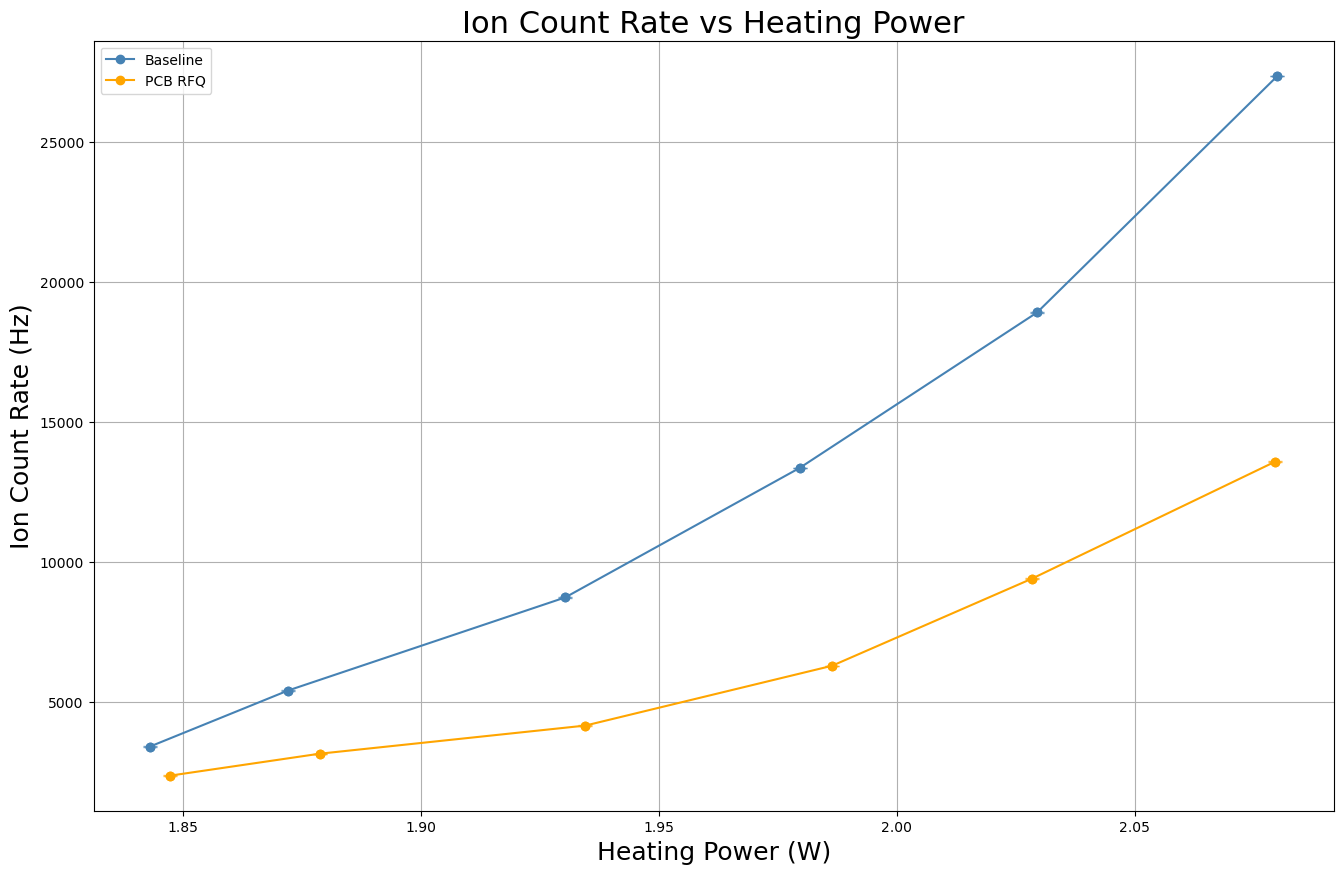

In [15]:
color = 'steelblue'
faded_color = mcolors.to_rgba(color, alpha=0.7)

plt.figure(figsize=(16, 10))

plt.plot(baseline['Power'], baseline['rate_hz'], marker='o', label='Baseline', color='steelblue')
plt.errorbar(baseline['Power'], baseline['rate_hz'], yerr=baseline['rate_err'],
             fmt='o', color='steelblue', ecolor=faded_color, elinewidth=3, capsize=5)
plt.plot(pcb_rfq['power'], pcb_rfq['rate_hz'], marker='o', label='PCB RFQ', color='orange')
plt.errorbar(pcb_rfq['power'], pcb_rfq['rate_hz'], yerr=pcb_rfq['rate_err'],
             fmt='o', color='orange', ecolor=mcolors.to_rgba('orange', alpha=0.7), elinewidth=3, capsize=5)
plt.xlabel('Heating Power (W)', fontsize=18)
plt.ylabel('Ion Count Rate (Hz)', fontsize=18)
plt.title('Ion Count Rate vs Heating Power', fontsize=22)
plt.legend()
plt.grid()
plt.show()

In [16]:
"""
Transmission efficiency per PCB RFQ point (Eq. 3.5-3.7): baseline rate/error
interpolated linearly to each PCB RFQ power, efficiency = detected/baseline x 100,
uncertainty propagated in quadrature from both relative uncertainties.
"""

baseline_vals = np.interp(pcb_rfq['power'], baseline['Power'], baseline['rate_hz'])
baseline_errs = np.interp(pcb_rfq['power'], baseline['Power'], baseline['rate_err'])

transmission_efficiency = pcb_rfq['rate_hz'] / baseline_vals * 100
transmission_efficiency_err = transmission_efficiency * np.sqrt(
    (pcb_rfq['rate_err'] / pcb_rfq['rate_hz'])**2 + (baseline_errs / baseline_vals)**2
)

mean_efficiency = np.mean(transmission_efficiency)
std_efficiency = np.std(transmission_efficiency, ddof=1)  # simple arithmetic mean + sample std, per §3.6.3

print(f"Transmission efficiency: {mean_efficiency:.3f} +/- {std_efficiency:.3f} % (statistical)")

Transmission efficiency: 51.301 +/- 7.076 % (statistical)


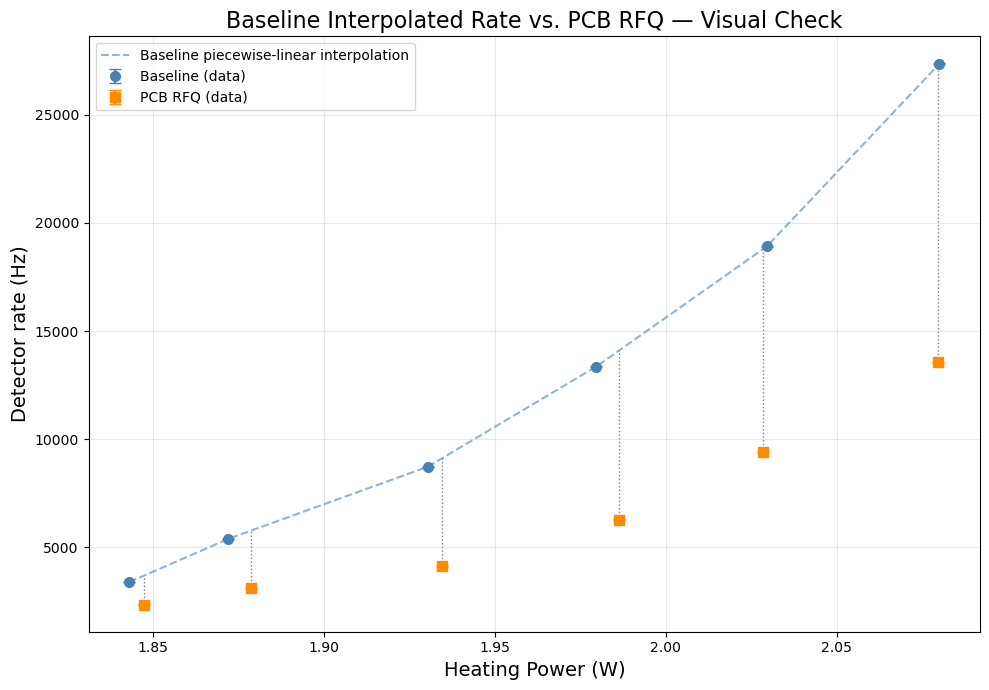

In [17]:
# Fine grid across the baseline's power range, to draw the interpolation as a smooth-looking line
power_grid = np.linspace(baseline['Power'].min(), baseline['Power'].max(), 300)
interp_curve = np.interp(power_grid, baseline['Power'], baseline['rate_hz'])

plt.figure(figsize=(10, 7))

plt.errorbar(baseline['Power'], baseline['rate_hz'], yerr=baseline['rate_err'], fmt="o", color="steelblue",
             capsize=4, markersize=7, label="Baseline (data)", zorder=3)
plt.plot(power_grid, interp_curve, "--", color="steelblue", alpha=0.6,
          label="Baseline piecewise-linear interpolation", zorder=2)

plt.errorbar(pcb_rfq['power'], pcb_rfq['rate_hz'], yerr=pcb_rfq['rate_err'], fmt="s", color="darkorange",
             capsize=4, markersize=7, label="PCB RFQ (data)", zorder=3)

# Show exactly where each PCB RFQ point's baseline was read off, for clarity
for p, r_pcb, b in zip(pcb_rfq['power'], pcb_rfq['rate_hz'], baseline_vals):
    plt.plot([p, p], [r_pcb, b], color="gray", linestyle=":", linewidth=1, zorder=1)

plt.xlabel("Heating Power (W)", fontsize=14)
plt.ylabel("Detector rate (Hz)", fontsize=14)
plt.title("Baseline Interpolated Rate vs. PCB RFQ — Visual Check", fontsize=16)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

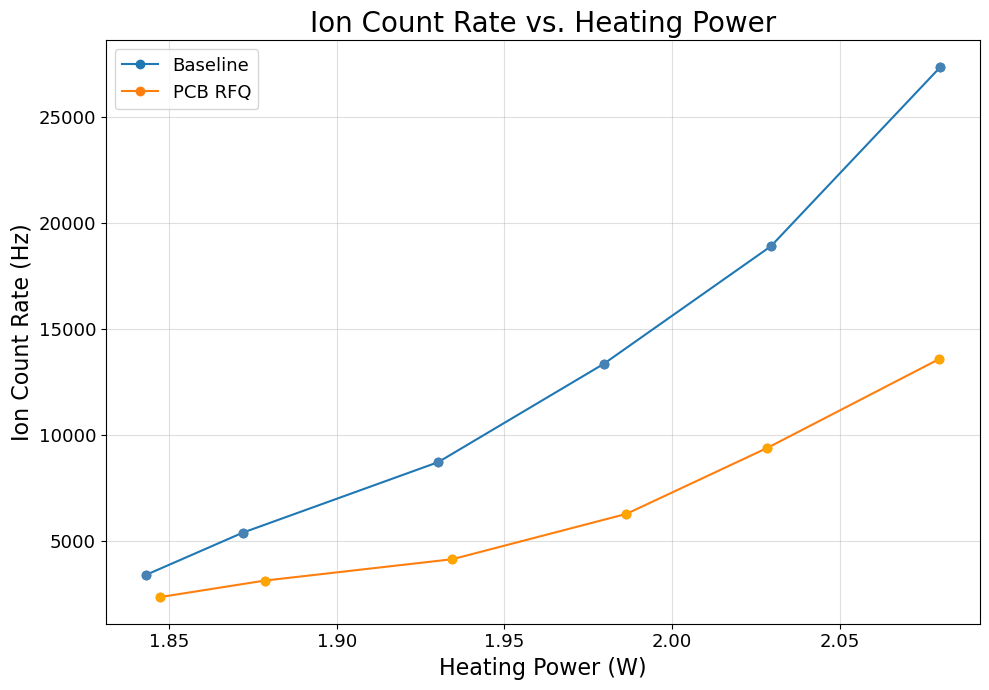

In [18]:
"""
Figure 4.1: Detector Count Rate vs. Source Heating Power — Baseline vs. PCB RFQ
------------------------------------------------------------------------------------
"""

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(baseline['Power'], baseline['rate_hz'], marker='o', label='Baseline')
ax.errorbar(baseline['Power'], baseline['rate_hz'], yerr=baseline['rate_err'], fmt='o', color='steelblue',
            ecolor=mcolors.to_rgba('steelblue', alpha=0.7), elinewidth=1, capsize=2)
ax.plot(pcb_rfq['power'], pcb_rfq['rate_hz'], marker='o', label='PCB RFQ')
ax.errorbar(pcb_rfq['power'], pcb_rfq['rate_hz'], yerr=pcb_rfq['rate_err'], fmt='o', color='orange',
            ecolor=mcolors.to_rgba('orange', alpha=0.7), elinewidth=1, capsize=2)
ax.set_xlabel('Heating Power (W)', fontsize=16)
ax.set_ylabel('Ion Count Rate (Hz)', fontsize=16)
ax.set_title('Ion Count Rate vs. Heating Power', fontsize=20)
ax.tick_params(labelsize=13)
ax.legend(fontsize=13)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [19]:
description = [
    "Detector Count Rate vs. Source Heating Power -- Baseline vs. PCB RFQ",
    "Corresponds to Figure 4.1",
    "",
    "Purpose: the core dataset for the PCB RFQ's transmission efficiency",
    "measurement (Table 4.1). Baseline was measured with only the source and",
    "detector installed, representing the total ion flux available for",
    "detection at a given heating power. PCB RFQ was measured with the PCB",
    "RFQ inserted into the beamline between them. Comparing detector rate at",
    "matched heating power between the two configurations isolates the",
    "fraction of ion flux lost during transport through the PCB RFQ. The two",
    "configurations were not measured at identical heating power settings,",
    "requiring interpolation (see Table 4.1) to compare them directly.",
    "",
    "Columns:",
    "  power_w      - Source heating power (W)",
    "  rate_hz      - Detector ion count rate (Hz)",
    "  rate_err_hz  - Detector rate uncertainty (Hz)",
    "  configuration - 'Baseline' or 'PCB RFQ'",
]

baseline_export = baseline[["Power", "rate_hz", "rate_err"]].copy()
baseline_export.columns = ["power_w", "rate_hz", "rate_err_hz"]
baseline_export["configuration"] = "Baseline"

pcb_rfq_export = pcb_rfq[["power", "rate_hz", "rate_err"]].copy()
pcb_rfq_export.columns = ["power_w", "rate_hz", "rate_err_hz"]
pcb_rfq_export["configuration"] = "PCB RFQ"

export_df_fig = pd.concat([baseline_export, pcb_rfq_export], ignore_index=True).sort_values(
    ["configuration", "power_w"]
).reset_index(drop=True)

export_figure_csv(export_df_fig, "thesis/rate_vs_power_configuration_comparison.csv", description)
print(export_df_fig)

    power_w       rate_hz  rate_err_hz configuration
0   1.84300   3393.849312     4.756137      Baseline
1   1.87200   5395.197365     5.997311      Baseline
2   1.93030   8725.237806     7.626379      Baseline
3   1.97960  13356.774409     9.434802      Baseline
4   2.02950  18913.982938    11.227627      Baseline
5   2.08000  27365.171198    13.505435      Baseline
6   1.84730   2354.814208     4.851236       PCB RFQ
7   1.87864   3136.666301     5.595813       PCB RFQ
8   1.93452   4143.044095     6.433368       PCB RFQ
9   1.98640   6281.726446     7.922170       PCB RFQ
10  2.02843   9396.414044     9.690749       PCB RFQ
11  2.07956  13579.956802    11.653074       PCB RFQ


In [20]:
description = [
    "Transmission Efficiency of the PCB RFQ",
    "Corresponds to Table 4.1",
    "",
    "Purpose: the headline transmission efficiency result of this thesis --",
    "the fraction of the baseline ion flux (Figure 4.1) that survives",
    "transport through the PCB RFQ, at each PCB RFQ heating power tested.",
    "Since the baseline and PCB RFQ configurations were not measured at",
    "identical heating power values, each PCB RFQ point's efficiency is",
    "computed against a baseline rate obtained by linear interpolation",
    "between the two nearest baseline measurements at neighboring powers.",
    "",
    "Columns:",
    "  power_w         - Source heating power (W), PCB RFQ setting",
    "  efficiency_pct  - Transmission efficiency at this power point (%)",
    "  efficiency_err_pct - Propagated per-point uncertainty (%)",
]

export_df_table = pd.DataFrame({
    "power_w": pcb_rfq["power"].values,
    "efficiency_pct": transmission_efficiency.values,
    "efficiency_err_pct": transmission_efficiency_err.values,
}).sort_values("power_w").reset_index(drop=True)

export_figure_csv(export_df_table, "thesis/efficiency_table_4_1.csv", description)
print(export_df_table)
print(f"\nOverall transmission efficiency: {mean_efficiency:.3f} +/- {std_efficiency:.3f} %")

   power_w  efficiency_pct  efficiency_err_pct
0  1.84730       63.805712            0.156759
1  1.87864       54.319573            0.113020
2  1.93452       45.419699            0.080470
3  1.98640       44.506841            0.063891
4  2.02843       49.994700            0.059535
5  2.07956       49.758857            0.049272

Overall transmission efficiency: 51.301 +/- 7.076 %


In [21]:
import shutil

def archive_raw_files(filenames, source_folder, dest_subfolder):
    """Copies the raw .mpa files underlying a given figure/table into their
    own subfolder under thesis/raw/, preserving full provenance."""
    dest_path = os.path.join("thesis", "raw", dest_subfolder)
    os.makedirs(dest_path, exist_ok=True)

    copied, missing = [], []
    for fname in filenames:
        src = os.path.join(source_folder, fname)
        dst = os.path.join(dest_path, fname)
        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied.append(fname)
        else:
            missing.append(fname)

    print(f"Copied {len(copied)} files to {dest_path}")
    if missing:
        print(f"WARNING: {len(missing)} files not found: {missing}")
    return copied, missing

# Figure 3.5 — Detector Rate vs Aperture Rate
archive_raw_files(baseline["file"].tolist(), "EfficiencyControl", "detector_vs_aperture_rate")
# Figure 4.1 / Table 4.1 — Rate vs Power Configuration Comparison
archive_raw_files(baseline["file"].tolist(), "EfficiencyControl", "rate_vs_power_configuration_comparison_baseline")
archive_raw_files(pcb_rfq["file"].tolist(), "EfficiencyControl", "rate_vs_power_configuration_comparison_pcb_rfq")

Copied 6 files to thesis/raw/detector_vs_aperture_rate
Copied 6 files to thesis/raw/rate_vs_power_configuration_comparison_baseline
Copied 6 files to thesis/raw/rate_vs_power_configuration_comparison_pcb_rfq


(['Efficiency1015_4.mpa',
  'Efficiency1021_4.mpa',
  'Efficiency1029_4.mpa',
  'Efficiency1040_4.mpa',
  'Efficiency1051_4.mpa',
  'Efficiency1061_4.mpa'],
 [])